# White Hat / Black Hat Options

This notebook proposes **five different pairs** of static visualizations for the assignment.

- **White hat** charts aim to be fair, transparent, and constructive.
- **Black hat** charts intentionally show how the same data can be made misleading through framing, truncation, cherry-picking, or distorted axes.

Dataset: `df_panel.csv` from the project **Who Pollutes, Who Pays?**

Practical note: for cross-variable comparisons this notebook uses **2021**, because 2022-2023 are much less complete for renewable energy and some other variables.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

panel = pd.read_csv('df_panel.csv')
focus_year = 2021
df = panel[panel['year'] == focus_year].copy()

region_colors = {
    'Europe & Central Asia': '#3b5a9d',
    'North America': '#f28e2b',
    'Latin America & Caribbean': '#59a14f',
    'East Asia & Pacific': '#e15759',
    'Middle East & North Africa': '#b07aa1',
    'Sub-Saharan Africa': '#76b7b2',
    'South Asia': '#edc948'
}

print('Focus year:', focus_year)
print('Countries in year slice:', len(df))
print('Countries with GDP + GHG:', df[['gdp_per_capita_ppp', 'ghg_per_capita']].dropna().shape[0])
print('Countries with GDP + GHG + electricity access:', df[['gdp_per_capita_ppp', 'ghg_per_capita', 'electricity_access_pct']].dropna().shape[0])

Focus year: 2021
Countries in year slice: 89
Countries with GDP + GHG: 84
Countries with GDP + GHG + electricity access: 84


## Option A: Regional renewable trend: full window vs cherry-picked slice

**White hat idea:** show the full available time series (2014–2021) of average renewable energy share for Europe & Central Asia, with a zero-based y-axis. Gradual, honest progress.

**Black hat idea:** zoom in on only 2019–2021, crop the y-axis to the data range, and shade the area below the line. The tiny 1-point gain over two years looks like a steep, dramatic surge.

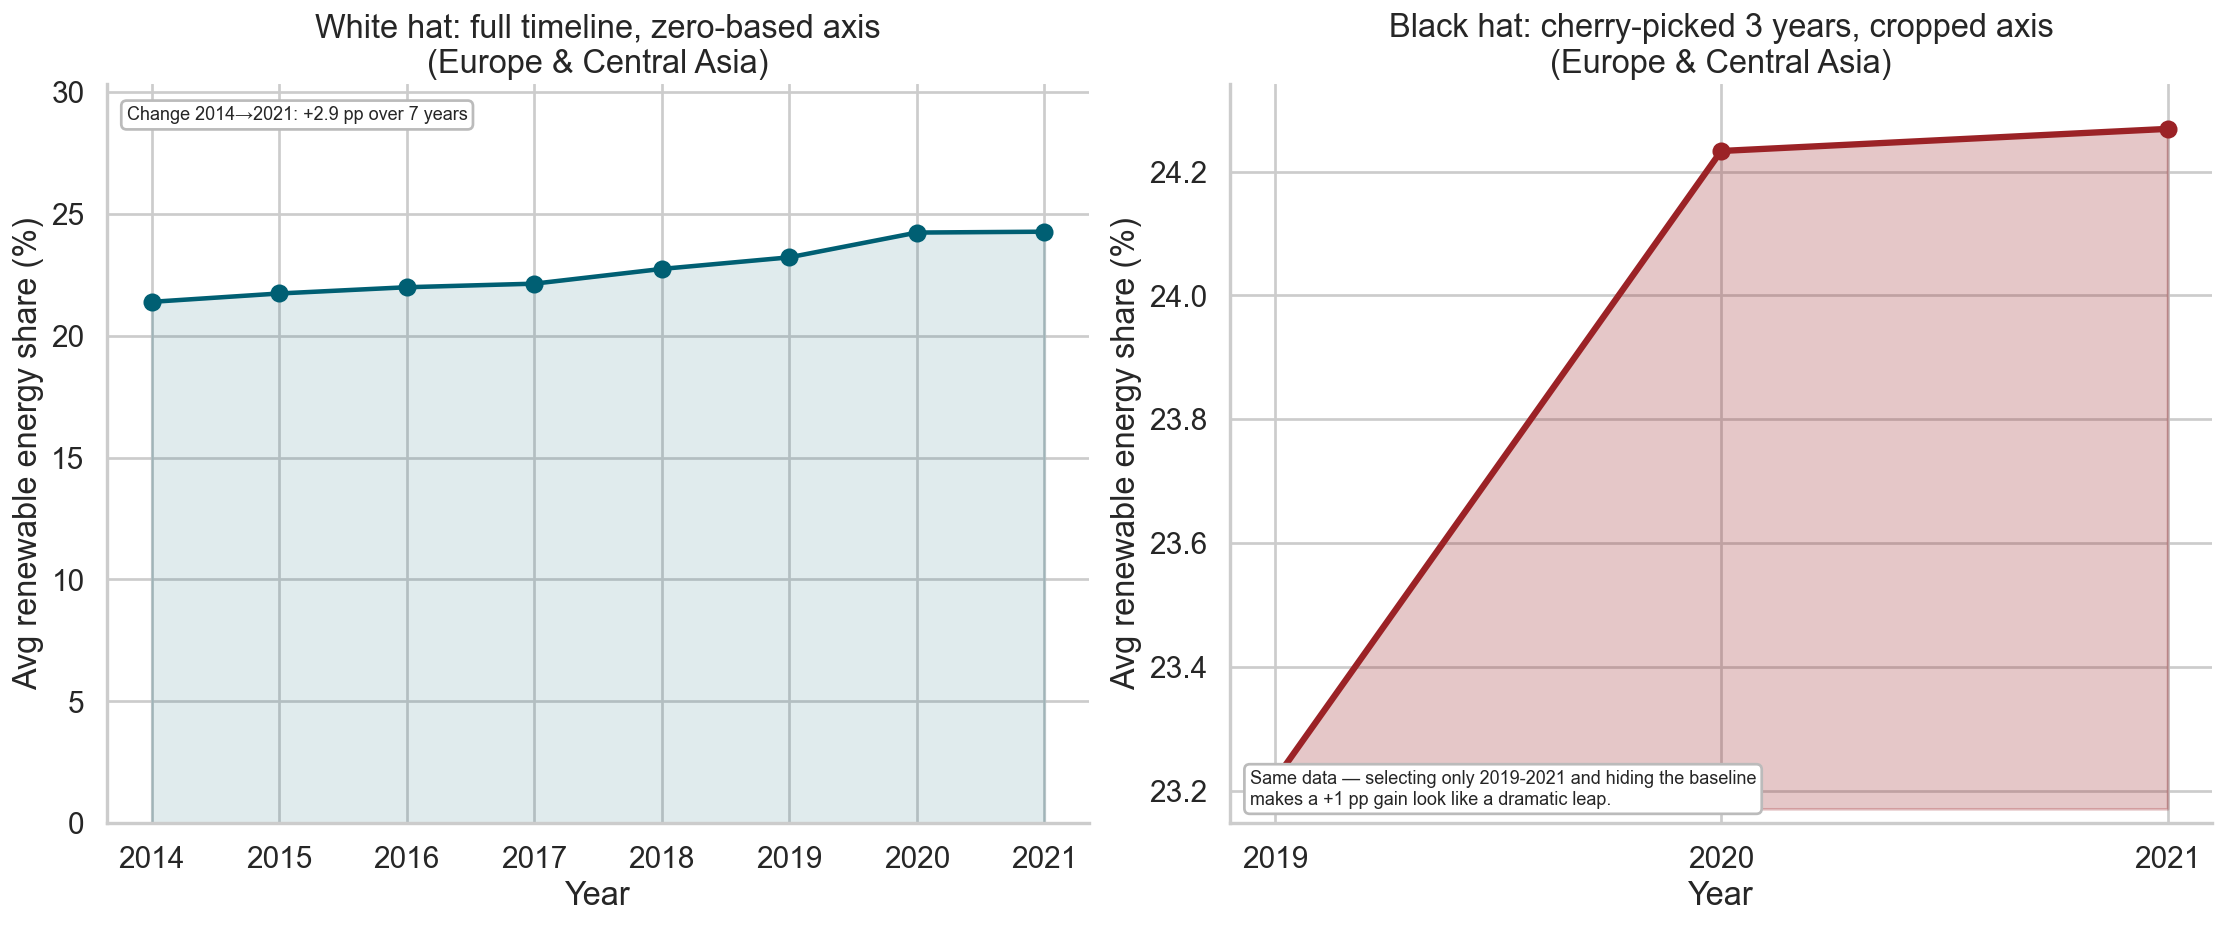

In [29]:
region_focus = 'Europe & Central Asia'

trend_r = (
    panel[panel['region'] == region_focus]
    .groupby('year')['renewable_pct']
    .mean()
    .dropna()
    .sort_index()
)
trend_r = trend_r[trend_r.index <= 2021]  # exclude incomplete 2022

cherry = trend_r[trend_r.index >= 2019]

fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)

# White hat: full range, zero-baseline
axes[0].plot(trend_r.index, trend_r.values, marker='o', linewidth=2.5, color='#005f73')
axes[0].fill_between(trend_r.index, trend_r.values, alpha=0.12, color='#005f73')
axes[0].set_ylim(0, trend_r.max() * 1.25)
axes[0].set_xticks(trend_r.index)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg renewable energy share (%)')
axes[0].set_title(f'White hat: full timeline, zero-based axis\n({region_focus})')
axes[0].text(
    0.02, 0.97,
    f'Change 2014→2021: +{trend_r[2021]-trend_r[2014]:.1f} pp over 7 years',
    transform=axes[0].transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bbbbbb')
)

# Black hat: cherry-picked 2019-2021, cropped y-axis, dramatic shading
axes[1].plot(cherry.index, cherry.values, marker='o', linewidth=3.5, color='#9b2226')
axes[1].fill_between(cherry.index, cherry.values, cherry.min() * 0.998, alpha=0.25, color='#9b2226')
y_lo = cherry.min() * 0.997
y_hi = cherry.max() * 1.003
axes[1].set_ylim(y_lo, y_hi)
axes[1].set_xticks(cherry.index)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg renewable energy share (%)')
axes[1].set_title(f'Black hat: cherry-picked 3 years, cropped axis\n({region_focus})')
axes[1].text(
    0.02, 0.02,
    'Same data — selecting only 2019-2021 and hiding the baseline\nmakes a +1 pp gain look like a dramatic leap.',
    transform=axes[1].transAxes, fontsize=10, va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bbbbbb')
)

plt.show()

## Option B: GHG per capita in Europe: long-term trend vs COVID window

**White hat idea**: show the full 2014–2021 series for Europe & Central Asia, with the y-axis starting from zero. The steady decline in emissions is clear and honest.

**Black hat idea**: select only 2019–2021 and truncate the y-axis to the data range. The 2020 low was due to COVID lockdowns; the 2021 rebound becomes visually a spike, suggesting that European emissions are increasing drammaticaly, which is not the case.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


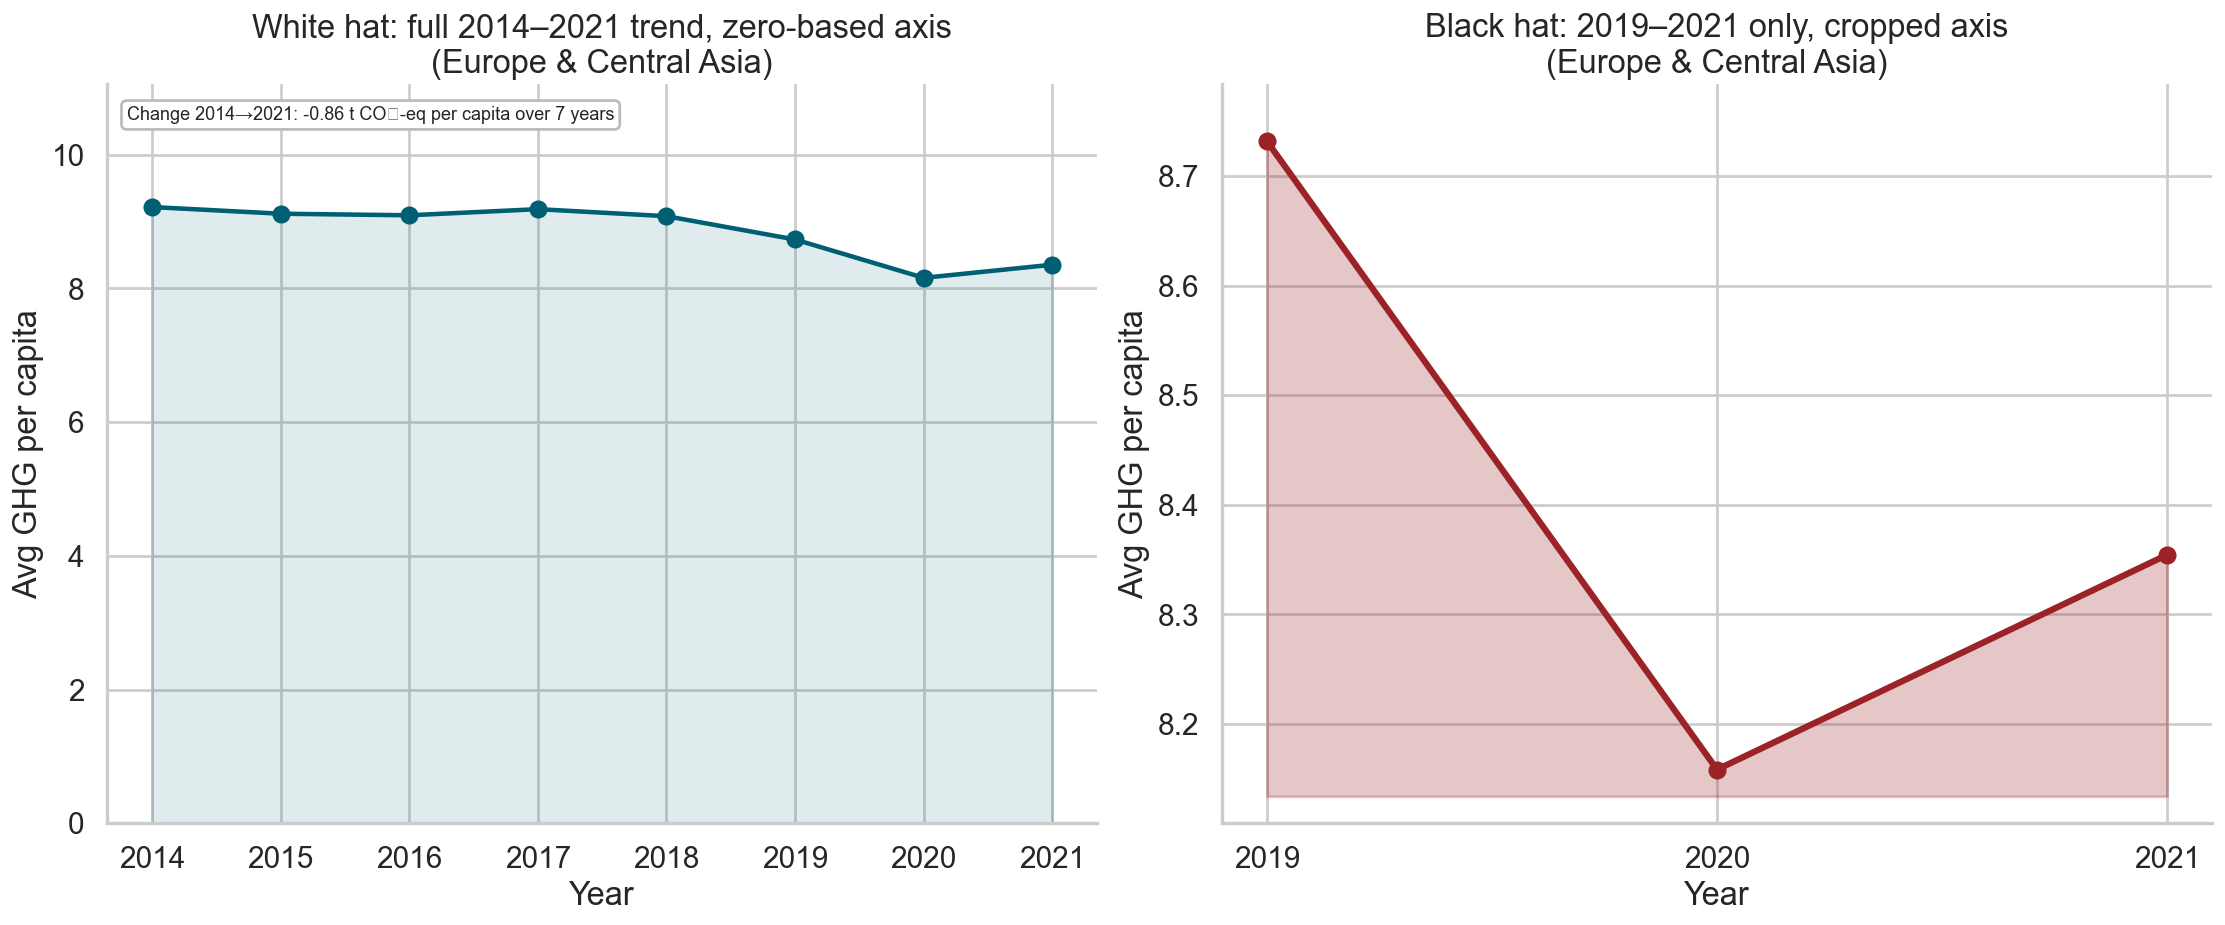

In [30]:
region_focus = 'Europe & Central Asia'

trend_ghg_eur = (
    panel[panel['region'] == region_focus]
    .groupby('year')['ghg_per_capita']
    .mean()
    .dropna()
    .sort_index()
)
trend_ghg_eur = trend_ghg_eur[trend_ghg_eur.index <= 2021]

cherry = trend_ghg_eur[trend_ghg_eur.index >= 2019]

fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)

axes[0].plot(trend_ghg_eur.index, trend_ghg_eur.values,
             marker='o', linewidth=2.5, color='#005f73')
axes[0].fill_between(trend_ghg_eur.index, trend_ghg_eur.values,
                     alpha=0.12, color='#005f73')
axes[0].set_ylim(0, trend_ghg_eur.max() * 1.2)
axes[0].set_xticks(trend_ghg_eur.index)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg GHG per capita')
axes[0].set_title(f'White hat: full 2014–2021 trend, zero-based axis\n({region_focus})')
total_change = trend_ghg_eur[2021] - trend_ghg_eur[2014]
axes[0].text(
    0.02, 0.97,
    f'Change 2014→2021: {total_change:+.2f} t CO₂-eq per capita over 7 years',
    transform=axes[0].transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bbbbbb')
)

axes[1].plot(cherry.index, cherry.values,
             marker='o', linewidth=3.5, color='#9b2226')
axes[1].fill_between(cherry.index, cherry.values, cherry.min() * 0.997,
                     alpha=0.25, color='#9b2226')
axes[1].set_ylim(cherry.min() * 0.994, cherry.max() * 1.006)
axes[1].set_xticks(cherry.index)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg GHG per capita')
axes[1].set_title(f'Black hat: 2019–2021 only, cropped axis\n({region_focus})')

plt.show()